# LOAD LIBRARIES

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from datetime import datetime
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet

# CONFIGURATION

In [80]:
START_DATE, END_DATE = '2023-11-08', '2024-08-21'
TARGET_FLUX = 'FN2O'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'time_blocks_eliza'
N_FOLDS = 10
LOG_TRANSFORM = True
UNDERSAMPLE = False
PERMUTATION_SEL = False
RFE_SEL = True

# LOAD DATA

In [81]:
data_main = fluxes = load_parquet(filepath=r"111.1_GapFillingDataset.parquet", sanitize_timestamp=False)
data_main = data_main.loc[START_DATE:END_DATE].copy()

data_main

Loaded .parquet file 111.1_GapFillingDataset.parquet (0.062 seconds).


,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.3_gfXG_diff24h,ts_0.3_gfXG_diff48h,ts_0.3_gfXG_diff72h,wfps_0.05_gfXG_diff24h,wfps_0.05_gfXG_diff48h,wfps_0.05_gfXG_diff72h,wfps_0.15_gfXG_diff24h,wfps_0.15_gfXG_diff48h,wfps_0.15_gfXG_diff72h,wfps_0.3_gfXG_diff24h,wfps_0.3_gfXG_diff48h,wfps_0.3_gfXG_diff72h,cropN_diff24h,cropN_diff48h,cropN_diff72h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.0,0.0,...,-0.228096,NaN,NaN,-3.610297,NaN,NaN,-1.038228,NaN,NaN,-3.108756,NaN,NaN,0.004965,NaN,NaN
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.0,0.0,...,-0.228096,NaN,NaN,-3.610297,NaN,NaN,-1.038228,NaN,NaN,-3.108756,NaN,NaN,0.003802,NaN,NaN
2023-11-19,24.046675,6.562,10.797847,15,8.130417,8.171039,7.473431,48.170499,55.860739,44.744259,33,60,33,0.0,0.0,...,-0.236815,-0.464911,NaN,2.353805,-1.256492,NaN,0.156375,-0.881853,NaN,0.933682,-2.175075,NaN,0.004047,0.007849,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-19,50.126077,0.153,16.706875,35,20.481689,20.822994,20.393482,37.491393,49.009887,42.875765,15,26,60,0.0,0.0,...,-0.936325,-1.834921,-2.049798,9.570889,20.544650,19.050566,7.280293,13.761413,12.138065,1.620507,1.965526,0.419208,0.000000,0.000000,0.0
2024-08-20,88.270955,0.000,18.696111,83,21.186513,21.047353,20.261765,35.316930,47.102637,42.942952,16,27,60,0.0,0.0,...,-0.131716,-1.068042,-1.966638,-2.174462,7.396426,18.370188,-1.907250,5.373043,11.854163,0.067188,1.687695,2.032713,0.000000,0.000000,0.0
2024-08-20,88.270955,0.000,18.696111,83,21.186513,21.047353,20.261765,35.316930,47.102637,42.942952,16,27,60,0.0,0.0,...,-0.131716,-1.068042,-1.966638,-2.174462,7.396426,18.370188,-1.907250,5.373043,11.854163,0.067188,1.687695,2.032713,0.000000,0.000000,0.0


# CLEAN DATA

In [82]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}')

# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove any flux variable with target flux except for the target itself
to_drop = [col for col in data.columns if TARGET_FLUX in col]
# Leave the target!
to_drop.remove(TARGET)
data.drop(columns=to_drop, inplace=True)

def clean_data(df, threshold=0.05):
    """Remove columns with too many missing values and non-numeric columns."""
    dropped_missing = df.columns[df.isna().mean() > threshold].tolist()
    df = df.drop(columns=dropped_missing)
    dropped_non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
    df = df.select_dtypes(include=[np.number])
    print(f"\nDropped {len(dropped_missing)} due to missing values: {dropped_missing}")
    print(f"\nDropped {len(dropped_non_numeric)} non-numeric columns: {dropped_non_numeric}")
    
    return df

data = clean_data(data)

data

The target variable is FN2O_L3.3_CUT_50_QCF0

Dropped 0 due to missing values: []

Dropped 0 non-numeric columns: []


,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.3_gfXG_diff24h,ts_0.3_gfXG_diff48h,ts_0.3_gfXG_diff72h,wfps_0.05_gfXG_diff24h,wfps_0.05_gfXG_diff48h,wfps_0.05_gfXG_diff72h,wfps_0.15_gfXG_diff24h,wfps_0.15_gfXG_diff48h,wfps_0.15_gfXG_diff72h,wfps_0.3_gfXG_diff24h,wfps_0.3_gfXG_diff48h,wfps_0.3_gfXG_diff72h,cropN_diff24h,cropN_diff48h,cropN_diff72h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.0,0.0,...,-0.228096,NaN,NaN,-3.610297,NaN,NaN,-1.038228,NaN,NaN,-3.108756,NaN,NaN,0.004965,NaN,NaN
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.0,0.0,...,-0.228096,NaN,NaN,-3.610297,NaN,NaN,-1.038228,NaN,NaN,-3.108756,NaN,NaN,0.003802,NaN,NaN
2023-11-19,24.046675,6.562,10.797847,15,8.130417,8.171039,7.473431,48.170499,55.860739,44.744259,33,60,33,0.0,0.0,...,-0.236815,-0.464911,NaN,2.353805,-1.256492,NaN,0.156375,-0.881853,NaN,0.933682,-2.175075,NaN,0.005286,0.010251,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-19,50.126077,0.153,16.706875,35,20.481689,20.822994,20.393482,37.491393,49.009887,42.875765,15,26,60,0.0,0.0,...,-0.936325,-1.834921,-2.049798,9.570889,20.544650,19.050566,7.280293,13.761413,12.138065,1.620507,1.965526,0.419208,0.000000,0.000000,0.0
2024-08-19,50.126077,0.153,16.706875,35,20.481689,20.822994,20.393482,37.491393,49.009887,42.875765,15,26,60,0.0,0.0,...,-0.936325,-1.834921,-2.049798,9.570889,20.544650,19.050566,7.280293,13.761413,12.138065,1.620507,1.965526,0.419208,0.000000,0.000000,0.0
2024-08-20,88.270955,0.000,18.696111,83,21.186513,21.047353,20.261765,35.316930,47.102637,42.942952,16,27,60,0.0,0.0,...,-0.131716,-1.068042,-1.966638,-2.174462,7.396426,18.370188,-1.907250,5.373043,11.854163,0.067188,1.687695,2.032713,0.000000,0.000000,0.0


# IMBALANCE HANDLING

## UNDER SAMPLING

In [83]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    fraction = 0.5
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling (keeping {fraction *100} % of data) target data below: {cutoff_value}')
    data[TARGET].plot(x_compat=True, style='.', title=f'Before undersampling')
    plt.show()
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=fraction, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.', title=f'After undersampling')
    plt.show()
else:
    print('\nThe target was not undersampled')


The target was not undersampled


## LOG TRANSFORMATION

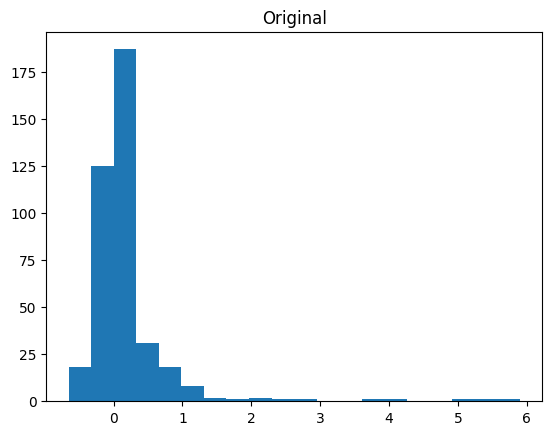

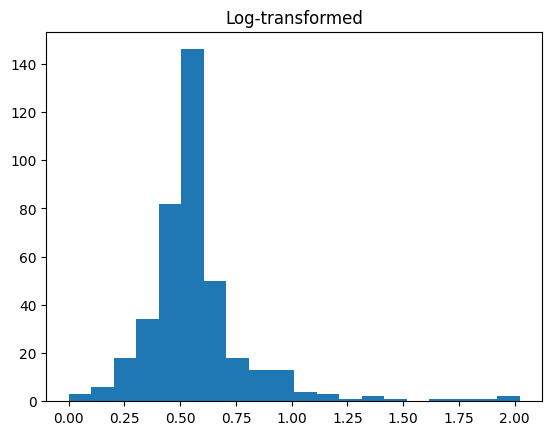

Log-tranformed
FN2O_L3.3_CUT_50_QCF0 was log-transformed


,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.3_gfXG_diff24h,ts_0.3_gfXG_diff48h,ts_0.3_gfXG_diff72h,wfps_0.05_gfXG_diff24h,wfps_0.05_gfXG_diff48h,wfps_0.05_gfXG_diff72h,wfps_0.15_gfXG_diff24h,wfps_0.15_gfXG_diff48h,wfps_0.15_gfXG_diff72h,wfps_0.3_gfXG_diff24h,wfps_0.3_gfXG_diff48h,wfps_0.3_gfXG_diff72h,cropN_diff24h,cropN_diff48h,cropN_diff72h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.0,0.0,...,-0.228096,NaN,NaN,-3.610297,NaN,NaN,-1.038228,NaN,NaN,-3.108756,NaN,NaN,0.004965,NaN,NaN
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.0,0.0,...,-0.228096,NaN,NaN,-3.610297,NaN,NaN,-1.038228,NaN,NaN,-3.108756,NaN,NaN,0.003802,NaN,NaN
2023-11-19,24.046675,6.562,10.797847,15,8.130417,8.171039,7.473431,48.170499,55.860739,44.744259,33,60,33,0.0,0.0,...,-0.236815,-0.464911,NaN,2.353805,-1.256492,NaN,0.156375,-0.881853,NaN,0.933682,-2.175075,NaN,0.005286,0.010251,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-19,50.126077,0.153,16.706875,35,20.481689,20.822994,20.393482,37.491393,49.009887,42.875765,15,26,60,0.0,0.0,...,-0.936325,-1.834921,-2.049798,9.570889,20.544650,19.050566,7.280293,13.761413,12.138065,1.620507,1.965526,0.419208,0.000000,0.000000,0.0
2024-08-19,50.126077,0.153,16.706875,35,20.481689,20.822994,20.393482,37.491393,49.009887,42.875765,15,26,60,0.0,0.0,...,-0.936325,-1.834921,-2.049798,9.570889,20.544650,19.050566,7.280293,13.761413,12.138065,1.620507,1.965526,0.419208,0.000000,0.000000,0.0
2024-08-20,88.270955,0.000,18.696111,83,21.186513,21.047353,20.261765,35.316930,47.102637,42.942952,16,27,60,0.0,0.0,...,-0.131716,-1.068042,-1.966638,-2.174462,7.396426,18.370188,-1.907250,5.373043,11.854163,0.067188,1.687695,2.032713,0.000000,0.000000,0.0


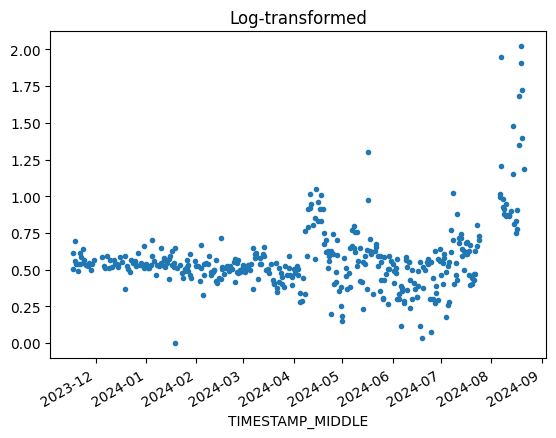

In [84]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

# Show histogram of non-tranformed and transformed TARGET
plt.hist(data[TARGET], bins=20)
plt.title('Original')
plt.show()
plt.hist(log_transform(data[TARGET]), bins=20)
plt.title('Log-transformed')
plt.show()

if LOG_TRANSFORM:
    print('Log-tranformed')
    data[TARGET] = log_transform(data[TARGET])
    print(f'{TARGET} was log-transformed')
    # Show log-transformed timeseries
    data[TARGET].plot(x_compat=True, style='.', title='Log-transformed');
else:
    print('\nLog-transformation of the target is not applied\n')

data

# CROSS-VAL SPLITS


Using time-blocks (2 records on average) splits for cross-validation



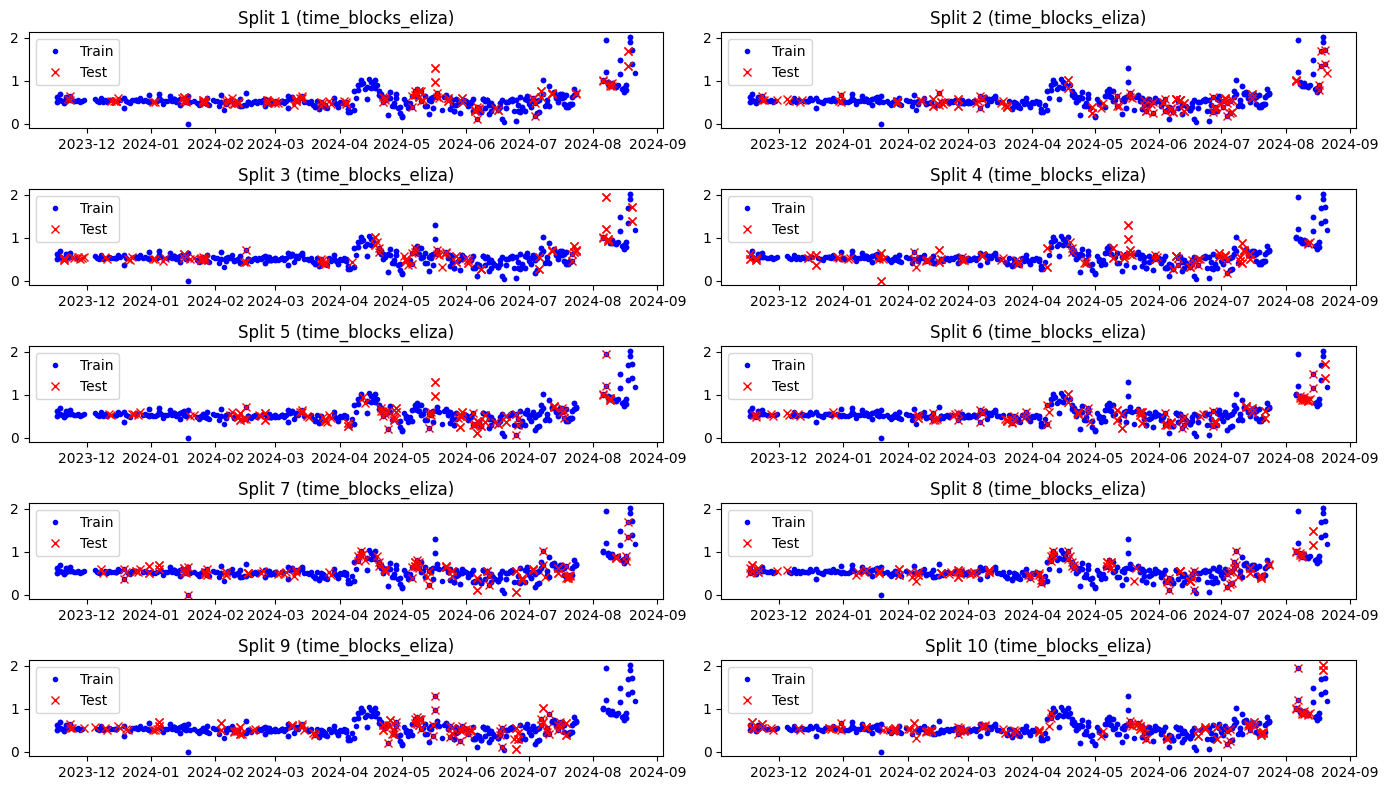

In [85]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
        print('\nUsing stratified random splits for cross-validation\n')
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)
        print('\nUsing stratified kfold splits for cross-validation\n')

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    block_size = 2 
    print(f'\nUsing time-blocks ({block_size} records on average) splits for cross-validation\n')
    def create_splits(X, y, n_folds, split=0.2, mean_block=block_size, min_block=1, random_state=42): # you can set mean block to mean_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits

X = data.drop(columns=TARGET)
y = data[TARGET]
# Create the splits using StratifiedShuffleSplit
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)


# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1} ({CROSSVAL_SPLIT})")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# FEATURE SELECTION

## Permutation importance

In [86]:
N_REPEATS = 5
N_RANDOMS = 10
def permutation_importance_selection(X, y, n_repeats=N_REPEATS, n_randoms=N_RANDOMS):
    iteration = 0
    # Generate random features ONCE and keep them throughout the iterations
    np.random.seed(42)  # Ensures reproducibility
    for i in range(n_randoms):
        X[f'random_{i}'] = np.random.permutation(len(X))

    while True:
        iteration += 1
        print(f"Iteration {iteration}: Starting with {X.shape[1] - n_randoms} features")

        model = RandomForestRegressor(n_estimators=100, min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1) \
            if MODEL_TYPE == 'RandomForest' else XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        importance_scores, rmse_scores, r2_scores = [], [], []

        for train_idx, test_idx in cross_val_splits:
            X_train, y_train, X_test, y_test = X.iloc[train_idx], y.iloc[train_idx], X.iloc[test_idx], y.iloc[test_idx]
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Invert the transformation if it was applied to calculate the performance with the original scale
            if LOG_TRANSFORM:
                y_test, y_pred = inverse_log_transform(y_test), inverse_log_transform(y_pred)

            perm_importance = permutation_importance(model, X_test, y_test, n_repeats=n_repeats, random_state=42, n_jobs=-1)
            importance_scores.append(perm_importance.importances_mean)
            rmse_scores.append(root_mean_squared_error(y_test, y_pred))
            r2_scores.append(r2_score(y_test, y_pred))

        mean_importance = np.mean(importance_scores, axis=0)
        threshold = np.mean(mean_importance[-n_randoms:])  # Use average of random features as threshold
        
        to_remove = [col for col in X.columns if mean_importance[X.columns.get_loc(col)] < threshold and not col.startswith('random_')]
        to_keep = [col for col in X.columns if col not in to_remove]
        print(f"Iteration {iteration}: Removed {len(to_remove)} features, RMSE: {np.mean(rmse_scores):.4f}, R²: {np.mean(r2_scores):.4f}")
        
        if len(to_remove) == 0:
            break  # Stop when no features are removed

        X = X[to_keep].copy()

    # Remove random features from final selection
    to_keep = [col for col in to_keep if not col.startswith('random_')]
    return to_keep

if PERMUTATION_SEL:
    to_keep = permutation_importance_selection(data.drop(columns=[TARGET]), data[TARGET])
    data = data[to_keep + [TARGET]]
    to_keep
else:
    print('Permutation importance based feature removal is not applied')

Permutation importance based feature removal is not applied


## Recursive feature elimination

Iteration 1: Remaining features: 71, Removed: timesince_harvest, RMSE: 0.4019, R²: 0.3923
Iteration 2: Remaining features: 70, Removed: timesince_fert_min, RMSE: 0.4019, R²: 0.3923
Iteration 3: Remaining features: 69, Removed: timesince_fert_org, RMSE: 0.4019, R²: 0.3923
Iteration 4: Remaining features: 68, Removed: GPP_NT_CUT_50_gfXG_QCF_roll24hsum, RMSE: 0.4019, R²: 0.3923
Iteration 5: Remaining features: 67, Removed: timesince_sowing, RMSE: 0.4019, R²: 0.3923
Iteration 6: Remaining features: 66, Removed: timesince_prec, RMSE: 0.4019, R²: 0.3924
Iteration 7: Remaining features: 65, Removed: ts_0.15_gfXG_diff72h, RMSE: 0.4037, R²: 0.3700
Iteration 8: Remaining features: 64, Removed: prec_lag24h, RMSE: 0.4030, R²: 0.3714
Iteration 9: Remaining features: 63, Removed: prec_lag48h, RMSE: 0.4051, R²: 0.3590
Iteration 10: Remaining features: 62, Removed: ts_0.3_gfXG_lag24h, RMSE: 0.4028, R²: 0.3719
Iteration 11: Remaining features: 61, Removed: ts_0.3_gfXG_diff24h, RMSE: 0.3998, R²: 0.3797


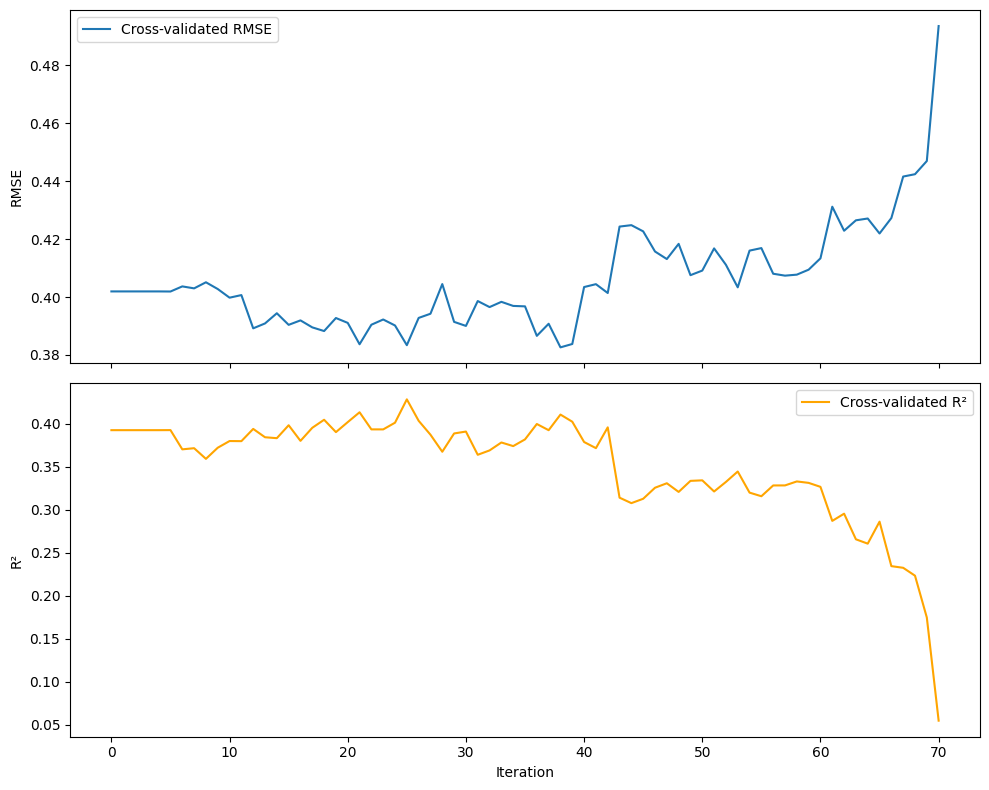


Best feature set found at iteration 26:
Selected Features: ['GPP_NT_CUT_50_gfXG_QCF', 'ta', 'ts_0.05_gfXG', 'ts_0.15_gfXG', 'wfps_0.05_gfXG', 'wfps_0.15_gfXG', 'wfps_0.3_gfXG', 'timesince_soil_preparation', 'n_decay_linear', 'n_decay_logistic', 'n_decay_exponential', 'n_decay_lognormal', 'cropN', 'trt', 'GPP_NT_CUT_50_gfXG_QCF_lag48h', 'GPP_NT_CUT_50_gfXG_QCF_lag72h', 'prec_lag72h', 'ta_lag48h', 'ta_lag72h', 'ts_0.05_gfXG_lag48h', 'ts_0.05_gfXG_lag72h', 'ts_0.15_gfXG_lag48h', 'ts_0.15_gfXG_lag72h', 'ts_0.3_gfXG_lag48h', 'ts_0.3_gfXG_lag72h', 'wfps_0.05_gfXG_lag24h', 'wfps_0.05_gfXG_lag48h', 'wfps_0.05_gfXG_lag72h', 'wfps_0.15_gfXG_lag24h', 'wfps_0.15_gfXG_lag48h', 'wfps_0.15_gfXG_lag72h', 'wfps_0.3_gfXG_lag24h', 'wfps_0.3_gfXG_lag48h', 'ts_0.05_gfXG_diff48h', 'ts_0.05_gfXG_diff72h', 'ts_0.15_gfXG_diff48h', 'ts_0.3_gfXG_diff72h', 'wfps_0.05_gfXG_diff24h', 'wfps_0.05_gfXG_diff48h', 'wfps_0.05_gfXG_diff72h', 'wfps_0.15_gfXG_diff48h', 'wfps_0.15_gfXG_diff72h', 'wfps_0.3_gfXG_diff24h', 'wf

In [87]:
def rfe_selection(X, y, cross_val_splits):
    performance = []
    iteration = 0
    features = list(X.columns)
    feature_removal_order = []  # Store removed features and their iteration index

    while len(features) > 1:
        iteration += 1
        rmse_scores, r2_scores, importances = [], [], []

        for train_idx, test_idx in cross_val_splits:
            X_train, y_train, X_test, y_test = X[features].iloc[train_idx], y.iloc[train_idx], X[features].iloc[test_idx], y.iloc[test_idx]
            model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) if MODEL_TYPE == 'RandomForest' else XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            # Invert the transformation if it was applied to calculate the performance with the original scale
            if LOG_TRANSFORM:
                y_test, y_pred = inverse_log_transform(y_test), inverse_log_transform(y_pred)
            
            rmse_scores.append(root_mean_squared_error(y_test, y_pred))
            r2_scores.append(r2_score(y_test, y_pred))
            importances.append(model.feature_importances_)

        mean_rmse = np.mean(rmse_scores)
        mean_r2 = np.mean(r2_scores)
        performance.append((features.copy(), mean_rmse, mean_r2))

        mean_importances = np.mean(importances, axis=0)
        least_important_index = np.argmin(mean_importances)
        least_important_feature = features.pop(least_important_index)

        # Store the removed feature with its iteration index
        feature_removal_order.append((least_important_feature, iteration))

        print(f"Iteration {iteration}: Remaining features: {len(features)}, Removed: {least_important_feature}, RMSE: {mean_rmse:.4f}, R²: {mean_r2:.4f}")

    # Extract RMSE and R² values
    rmse_values = [score[1] for score in performance]
    r2_values = [score[2] for score in performance]

    # Plot RMSE and R² over iterations
    fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    axs[0].plot(range(len(performance)), rmse_values, label="Cross-validated RMSE")
    axs[0].set_ylabel("RMSE")
    axs[0].legend()

    axs[1].plot(range(len(performance)), r2_values, label="Cross-validated R²", color="orange")
    axs[1].set_xlabel("Iteration")
    axs[1].set_ylabel("R²")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    # Select best feature set by minimizing both R² and RMSE and penlizing larger feature sets
    # Normalize RMSE and R²
    norm_rmse = (np.array(rmse_values) - min(rmse_values)) / (max(rmse_values) - min(rmse_values))
    norm_r2 = (np.array(r2_values) - min(r2_values)) / (max(r2_values) - min(r2_values))
    # Set weights for normalized metrics
    w_rmse, w_r2, w_penalty = 0.5, 0.5, 0.001  # Adjust w_penalty as needed
    # Calculate composite scores with normalized metrics and feature count penalty
    composite_scores = [
        (performance[i][0], # Features
         i + 1, # Iteration number
        w_rmse * norm_rmse[i] + w_r2 * (1 - norm_r2[i]) + w_penalty * len(performance[i][0])  # Composite score
        )  
        for i in range(len(performance))
    ]

    # Find the feature subset with the best (lowest) composite score
    best_features, best_iteration, _ = min(composite_scores, key=lambda x: x[2])

    # Add the final remaining feature
    feature_removal_order.append((features[0], iteration + 1))

    # Rank features based on removal order
    feature_ranking = [feature for feature, _ in sorted(feature_removal_order, key=lambda x: x[1], reverse=True)]

    # Print the best feature set details
    print(f"\nBest feature set found at iteration {best_iteration}:")
    print(f"Selected Features: {best_features}")
    print(f"Performance - RMSE: {rmse_values[best_iteration-1]:.4f}, R²: {r2_values[best_iteration-1]:.4f}")

    return best_features, feature_ranking

if RFE_SEL:
    selected_features, ranked_features = rfe_selection(data.drop(columns=[TARGET]), data[TARGET], cross_val_splits= cross_val_splits)
    # Update the main dataframe
    data = data[selected_features + [TARGET]]
else:
    print('Recursive Feature Elimination is not applied')

# EXPORT 

In [88]:
filename = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(filename, 'w') as f:
    for item in selected_features:
        f.write(f"{item}\n")

filename = 'ranked_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(filename, 'w') as f:
    for item in ranked_features:
        f.write(f"{item}\n")

# **End of notebook**

In [89]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-01-09 11:41:00
